# 11. Analysis: COMET Pipeline

This notebook is the main analysis notebook for the project. It uses the validated COMET outputs and merged automatic metrics as the current source of truth, and it is designed to incorporate human evaluation results later once annotation is complete.

## Scope
- Compare baseline, idiom-only, LoRA, and FLAN models
- Analyze performance on both `idioms_test` and `wmt_test`
- Use COMET as the primary semantic metric
- Use BLEU and chrF as supporting automatic metrics
- Reserve a dedicated section for human evaluation once available


# 0. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path('/content/drive/MyDrive/ds266_idiom_mt')
RESULTS_DIR = PROJECT_DIR / 'results'
COMET_EVAL_DIR = PROJECT_DIR / 'qual_preds' / 'comet_eval'

FILES = {
    'automatic_plus_comet': RESULTS_DIR / 'automatic_plus_comet.csv',
    'comet_sentence_scores': COMET_EVAL_DIR / 'comet_sentence_scores.csv',
    'comet_sentence_spread': COMET_EVAL_DIR / 'comet_sentence_spread.csv',
    'comet_summary_by_group': COMET_EVAL_DIR / 'comet_summary_by_group.csv',
    'comet_summary_overall': COMET_EVAL_DIR / 'comet_summary_overall.csv',
}

for name, path in FILES.items():
    print(f'{name}: {path} | exists={path.exists()}')


automatic_plus_comet: /content/drive/MyDrive/ds266_idiom_mt/results/automatic_plus_comet.csv | exists=True
comet_sentence_scores: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_sentence_scores.csv | exists=True
comet_sentence_spread: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_sentence_spread.csv | exists=True
comet_summary_by_group: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_summary_by_group.csv | exists=True
comet_summary_overall: /content/drive/MyDrive/ds266_idiom_mt/qual_preds/comet_eval/comet_summary_overall.csv | exists=True


## 2. Load Data Sources

In [3]:
scores = pd.read_csv(FILES['comet_sentence_scores'])
spread = pd.read_csv(FILES['comet_sentence_spread'])
summary_by_group = pd.read_csv(FILES['comet_summary_by_group'])
summary_overall = pd.read_csv(FILES['comet_summary_overall'])
merged_metrics = pd.read_csv(FILES['automatic_plus_comet'])

print('Loaded successfully.')
print('scores:', scores.shape)
print('spread:', spread.shape)
print('summary_by_group:', summary_by_group.shape)
print('summary_overall:', summary_overall.shape)
print('merged_metrics:', merged_metrics.shape)


Loaded successfully.
scores: (450, 11)
spread: (50, 15)
summary_by_group: (18, 6)
summary_overall: (9, 5)
merged_metrics: (18, 13)


## 3. Input data validation

These checks help confirm that the notebook is using the expected source-of-truth files.

In [4]:
print('Duplicate (src, model, group) rows:', scores.duplicated(['src', 'model', 'group']).sum())
print('\nRows per (group, model):')
display(scores.groupby(['group', 'model']).size().rename('n_rows').reset_index())

print('\nModels present in sentence-level scores:')
display(pd.Series(sorted(scores['model'].unique()), name='model'))

Duplicate (src, model, group) rows: 0

Rows per (group, model):


,group,model,n_rows
0,idioms_test,baseline,25
1,idioms_test,flan_t5_small_prompt_0shot,25
2,idioms_test,flan_t5_small_prompt_3shot,25
3,idioms_test,flan_t5_small_prompt_5shot,25
4,idioms_test,idiom_only_v1,25
5,idioms_test,lora_r16_stage2,25
6,idioms_test,lora_r4_stage2,25
7,idioms_test,lora_r8_stage2,25
8,idioms_test,two_stage_frozen_v1,25
9,wmt_test,baseline,25



Models present in sentence-level scores:


,model
0,baseline
1,flan_t5_small_prompt_0shot
2,flan_t5_small_prompt_3shot
3,flan_t5_small_prompt_5shot
4,idiom_only_v1
5,lora_r16_stage2
6,lora_r4_stage2
7,lora_r8_stage2
8,two_stage_frozen_v1


## 4. Compared models

In [5]:
model_notes = pd.DataFrame({
    'model': [
        'baseline',
        'idiom_only_v1',
        'lora_r4_stage2',
        'lora_r8_stage2',
        'lora_r16_stage2',
        'flan_t5_small_prompt_0shot',
        'flan_t5_small_prompt_3shot',
        'flan_t5_small_prompt_5shot',
    ],
    'family': [
        'Helsinki baseline',
        'Full fine-tune',
        'LoRA',
        'LoRA',
        'LoRA',
        'FLAN prompting',
        'FLAN prompting',
        'FLAN prompting',
    ],
    'notes': [
        'Pretrained EN→DE baseline',
        'Stage 1 idiom-only fine-tune',
        'Two-stage LoRA rank 4',
        'Two-stage LoRA rank 8',
        'Two-stage LoRA rank 16',
        'FLAN 0-shot',
        'FLAN 3-shot',
        'FLAN 5-shot',
    ]
})

display(model_notes)

,model,family,notes
0,baseline,Helsinki baseline,Pretrained EN→DE baseline
1,idiom_only_v1,Full fine-tune,Stage 1 idiom-only fine-tune
2,lora_r4_stage2,LoRA,Two-stage LoRA rank 4
3,lora_r8_stage2,LoRA,Two-stage LoRA rank 8
4,lora_r16_stage2,LoRA,Two-stage LoRA rank 16
5,flan_t5_small_prompt_0shot,FLAN prompting,FLAN 0-shot
6,flan_t5_small_prompt_3shot,FLAN prompting,FLAN 3-shot
7,flan_t5_small_prompt_5shot,FLAN prompting,FLAN 5-shot


## 5. Quantitative results overview

In [6]:
display(summary_by_group.sort_values(['group', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))


,model,group,n,comet_mean,comet_std,input_sources
0,idiom_only_v1,idioms_test,25,0.762717,0.133694,wide_csv
1,two_stage_frozen_v1,idioms_test,25,0.760963,0.135645,wide_csv
2,lora_r16_stage2,idioms_test,25,0.732651,0.143304,wide_csv
3,baseline,idioms_test,25,0.732551,0.135191,wide_csv
4,lora_r8_stage2,idioms_test,25,0.732034,0.147128,wide_csv
5,lora_r4_stage2,idioms_test,25,0.728579,0.152061,wide_csv
6,flan_t5_small_prompt_0shot,idioms_test,25,0.381018,0.118532,per_model_csvs
7,flan_t5_small_prompt_5shot,idioms_test,25,0.371568,0.127203,per_model_csvs
8,flan_t5_small_prompt_3shot,idioms_test,25,0.363405,0.106758,per_model_csvs
9,idiom_only_v1,wmt_test,25,0.863072,0.070707,wide_csv


In [7]:
display(summary_overall.sort_values('comet_mean', ascending=False).reset_index(drop=True))


,model,n,comet_mean,comet_std,input_sources
0,idiom_only_v1,50,0.812894,0.117357,wide_csv
1,two_stage_frozen_v1,50,0.803841,0.122186,wide_csv
2,lora_r16_stage2,50,0.789763,0.133208,wide_csv
3,lora_r8_stage2,50,0.787165,0.137748,wide_csv
4,baseline,50,0.782859,0.133687,wide_csv
5,lora_r4_stage2,50,0.780935,0.143225,wide_csv
6,flan_t5_small_prompt_0shot,50,0.427297,0.135950,per_model_csvs
7,flan_t5_small_prompt_3shot,50,0.426677,0.145595,per_model_csvs
8,flan_t5_small_prompt_5shot,50,0.402114,0.137224,per_model_csvs


### Supporting automatic metrics (COMET + BLEU + chrF)

In [8]:
display(merged_metrics.sort_values(['split', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))


,timestamp,model,model_label,split,bleu,chrf,source_notebook,source_run_name,notes,n,comet_mean,comet_std,input_sources
0,2026-03-28T21:13:36-07:00,idiom_only_v1,idiom_only_v1,idioms_test,44.161210,64.438061,01_experiment_idiom_aware_MT_two_stage_frozen_...,idiom_only_v1,stage1 idiom-only fine-tune,25,0.762717,0.133694,wide_csv
1,2026-03-28T21:15:29-07:00,two_stage_frozen_v1,two_stage_frozen_v1,idioms_test,43.159787,63.341618,01_experiment_idiom_aware_MT_two_stage_frozen_...,two_stage_frozen_v1,"stage2 general fine-tune, encoder frozen (eval...",25,0.760963,0.135645,wide_csv
2,2026-03-28T23:08:03-07:00,lora_r16_stage2,lora_r16_stage2,idioms_test,41.724245,61.449820,04_experiment_idiom_aware_MT_PEFT_LoRA_RANK.ipynb,lora_r16_two_stage_greedy,LoRA 2-stage | r=16 | stage2=WMT enc_frozen | ...,25,0.732651,0.143304,wide_csv
3,2026-03-28T21:11:44-07:00,baseline,baseline,idioms_test,39.649352,60.786112,01_experiment_idiom_aware_MT_two_stage_frozen_...,baseline,pretrained baseline,25,0.732551,0.135191,wide_csv
4,2026-03-28T22:48:35-07:00,lora_r8_stage2,lora_r8_stage2,idioms_test,42.178766,61.760909,04_experiment_idiom_aware_MT_PEFT_LoRA_RANK.ipynb,lora_r8_two_stage_greedy,LoRA 2-stage | r=8 | stage2=WMT enc_frozen | s...,25,0.732034,0.147128,wide_csv
5,2026-03-28T22:29:15-07:00,lora_r4_stage2,lora_r4_stage2,idioms_test,41.853197,61.836284,04_experiment_idiom_aware_MT_PEFT_LoRA_RANK.ipynb,lora_r4_two_stage_greedy,LoRA 2-stage | r=4 | stage2=WMT enc_frozen | s...,25,0.728579,0.152061,wide_csv
6,2026-03-29T12:33:08-07:00,flan_t5_small_prompt_0shot,flan_t5_small_prompt_0shot,idioms_test,8.126810,33.138795,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_0shot,few-shot prompted baseline on idiom subset,25,0.381018,0.118532,per_model_csvs
7,2026-03-29T12:38:49-07:00,flan_t5_small_prompt_5shot,flan_t5_small_prompt_5shot,idioms_test,7.623039,32.096459,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_5shot,few-shot prompted baseline on idiom subset,25,0.371568,0.127203,per_model_csvs
8,2026-03-29T12:35:43-07:00,flan_t5_small_prompt_3shot,flan_t5_small_prompt_3shot,idioms_test,7.769178,32.517583,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_3shot,few-shot prompted baseline on idiom subset,25,0.363405,0.106758,per_model_csvs
9,2026-03-28T21:15:21-07:00,idiom_only_v1,idiom_only_v1,wmt_test,26.540147,58.230959,01_experiment_idiom_aware_MT_two_stage_frozen_...,idiom_only_v1,stage1 idiom-only fine-tune (eval on WMT),25,0.863072,0.070707,wide_csv


## 6. FLAN variant comparison

This section compares FLAN 0-shot, 3-shot, and 5-shot across the two evaluation groups. The goal is to justify the single FLAN variant later selected for human annotation.

In [9]:
flan_by_group = summary_by_group[summary_by_group['model'].str.contains('flan_t5_small_prompt')].copy()
flan_overall = summary_overall[summary_overall['model'].str.contains('flan_t5_small_prompt')].copy()
flan_merged = merged_metrics[merged_metrics['model_label'].str.contains('flan_t5_small_prompt')].copy()

print('FLAN by group:')
display(flan_by_group.sort_values(['group', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))

print('FLAN overall:')
display(flan_overall.sort_values('comet_mean', ascending=False).reset_index(drop=True))

print('FLAN merged metrics:')
display(flan_merged.sort_values(['split', 'comet_mean'], ascending=[True, False]).reset_index(drop=True))


FLAN by group:


,model,group,n,comet_mean,comet_std,input_sources
0,flan_t5_small_prompt_0shot,idioms_test,25,0.381018,0.118532,per_model_csvs
1,flan_t5_small_prompt_5shot,idioms_test,25,0.371568,0.127203,per_model_csvs
2,flan_t5_small_prompt_3shot,idioms_test,25,0.363405,0.106758,per_model_csvs
3,flan_t5_small_prompt_3shot,wmt_test,25,0.489949,0.153432,per_model_csvs
4,flan_t5_small_prompt_0shot,wmt_test,25,0.473576,0.138647,per_model_csvs
5,flan_t5_small_prompt_5shot,wmt_test,25,0.432660,0.142552,per_model_csvs


FLAN overall:


,model,n,comet_mean,comet_std,input_sources
0,flan_t5_small_prompt_0shot,50,0.427297,0.135950,per_model_csvs
1,flan_t5_small_prompt_3shot,50,0.426677,0.145595,per_model_csvs
2,flan_t5_small_prompt_5shot,50,0.402114,0.137224,per_model_csvs


FLAN merged metrics:


,timestamp,model,model_label,split,bleu,chrf,source_notebook,source_run_name,notes,n,comet_mean,comet_std,input_sources
0,2026-03-29T12:33:08-07:00,flan_t5_small_prompt_0shot,flan_t5_small_prompt_0shot,idioms_test,8.126810,33.138795,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_0shot,few-shot prompted baseline on idiom subset,25,0.381018,0.118532,per_model_csvs
1,2026-03-29T12:38:49-07:00,flan_t5_small_prompt_5shot,flan_t5_small_prompt_5shot,idioms_test,7.623039,32.096459,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_5shot,few-shot prompted baseline on idiom subset,25,0.371568,0.127203,per_model_csvs
2,2026-03-29T12:35:43-07:00,flan_t5_small_prompt_3shot,flan_t5_small_prompt_3shot,idioms_test,7.769178,32.517583,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_3shot,few-shot prompted baseline on idiom subset,25,0.363405,0.106758,per_model_csvs
3,2026-03-29T12:40:10-07:00,flan_t5_small_prompt_3shot,flan_t5_small_prompt_3shot,wmt_test,7.431623,36.224973,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_3shot_wmt25,3-shot prompted baseline on canonical 25-examp...,25,0.489949,0.153432,per_model_csvs
4,2026-03-29T12:39:15-07:00,flan_t5_small_prompt_0shot,flan_t5_small_prompt_0shot,wmt_test,7.615428,35.542535,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_0shot_wmt25,0-shot prompted baseline on canonical 25-examp...,25,0.473576,0.138647,per_model_csvs
5,2026-03-29T12:41:12-07:00,flan_t5_small_prompt_5shot,flan_t5_small_prompt_5shot,wmt_test,4.958042,29.858081,06_experiment_idiom_aware_MT_fewshot_prompting...,flan_t5_small_prompt_5shot_wmt25,5-shot prompted baseline on canonical 25-examp...,25,0.432660,0.142552,per_model_csvs


### Interim interpretation

Use this section to record which FLAN variant performs best on idioms, which performs best on WMT, and which one should be used for the blinded annotation package.

## 7. Tradeoff analysis across models

This section compares idiom performance against WMT performance to examine the specialization vs generalization tradeoff.

In [10]:
tradeoff = summary_by_group.pivot(index='model', columns='group', values='comet_mean').reset_index()
tradeoff.columns.name = None
tradeoff = tradeoff.rename(columns={
    'idioms_test': 'idioms_comet',
    'wmt_test': 'wmt_comet'
})

baseline_idioms = tradeoff.loc[tradeoff['model'] == 'baseline', 'idioms_comet'].iloc[0]
baseline_wmt = tradeoff.loc[tradeoff['model'] == 'baseline', 'wmt_comet'].iloc[0]

tradeoff['idioms_vs_baseline'] = tradeoff['idioms_comet'] - baseline_idioms
tradeoff['wmt_vs_baseline'] = tradeoff['wmt_comet'] - baseline_wmt

display(tradeoff.sort_values('idioms_comet', ascending=False).reset_index(drop=True))


,model,idioms_comet,wmt_comet,idioms_vs_baseline,wmt_vs_baseline
0,idiom_only_v1,0.762717,0.863072,0.030166,0.029905
1,two_stage_frozen_v1,0.760963,0.846719,0.028412,0.013552
2,lora_r16_stage2,0.732651,0.846875,0.000100,0.013708
3,baseline,0.732551,0.833167,0.000000,0.000000
4,lora_r8_stage2,0.732034,0.842295,-0.000517,0.009128
5,lora_r4_stage2,0.728579,0.833291,-0.003972,0.000124
6,flan_t5_small_prompt_0shot,0.381018,0.473576,-0.351533,-0.359591
7,flan_t5_small_prompt_5shot,0.371568,0.432660,-0.360983,-0.400507
8,flan_t5_small_prompt_3shot,0.363405,0.489949,-0.369146,-0.343217


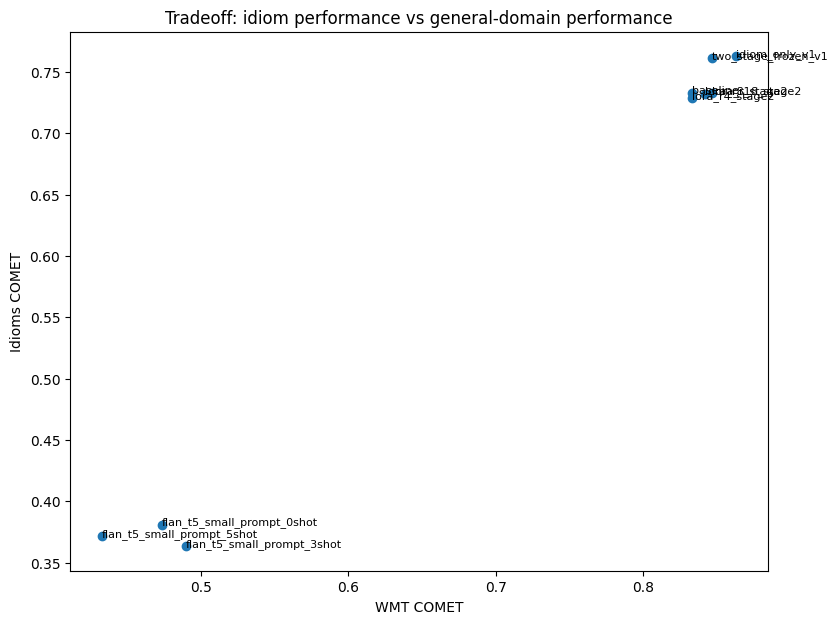

In [11]:
plot_df = tradeoff.copy()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(plot_df['wmt_comet'], plot_df['idioms_comet'])

for _, row in plot_df.iterrows():
    ax.annotate(row['model'], (row['wmt_comet'], row['idioms_comet']), fontsize=8)

ax.set_xlabel('WMT COMET')
ax.set_ylabel('Idioms COMET')
ax.set_title('Tradeoff: idiom performance vs general-domain performance')
plt.show()


## 8. Sentence-level qualitative analysis

This section uses sentence-level spread to identify examples where the models disagree most strongly. These are often the best candidates for qualitative discussion in the paper.

In [12]:
high_spread = spread.sort_values('comet_spread', ascending=False).head(10)
display(high_spread[['group', 'src', 'ref', 'comet_min', 'comet_max', 'comet_spread']])

,group,src,ref,comet_min,comet_max,comet_spread
0,idioms_test,But before she could launch her charm offensiv...,Doch bevor sie ihre Charmeoffensive starten ko...,0.169645,0.945956,0.776311
1,idioms_test,"Bend the knee, peasant! Admit that I am your r...","Beuge das Knie, Bauer! Gib zu, dass ich dein r...",0.282064,0.917172,0.635108
2,idioms_test,"For the young Canadian servicemen, the order t...",Die jungen kanadischen Soldaten erwarteten täg...,0.180694,0.812785,0.632091
25,wmt_test,"However, if no new orders are announced in the...",Falls allerdings in den kommenden Monaten kein...,0.295748,0.918535,0.622787
26,wmt_test,All three face a maximum penalty of life impri...,Allen dreien droht als Höchststrafe lebenslang...,0.271974,0.889371,0.617396
27,wmt_test,"Meanwhile, U.S. lawmakers will head to Europe ...",Unterdessen werden US-amerikanische Gesetzgebe...,0.267089,0.882884,0.615794
28,wmt_test,"""Decisions will then be made elsewhere,"" said ...","""Dann werden Entscheidungen an anderer Stelle ...",0.333581,0.943284,0.609703
29,wmt_test,Howie was also ordered to pay costs of £90 and...,Howie wurde außerdem zur Zahlung von Kosten in...,0.319074,0.908975,0.589901
3,idioms_test,"""Regardless of their cause, inequalities are a...","""Unabhängig von ihrer Ursache sind Ungleichhei...",0.290774,0.876986,0.586211
4,idioms_test,We're cut from the same cloth as any American ...,Wir sind aus dem gleichen Holz geschnitzt wie ...,0.336061,0.907208,0.571148


### Example inspection helper

Use this cell to inspect all model outputs for a selected sentence.

In [13]:
example_idx = 0  # change this to inspect different rows from high_spread
row = high_spread.iloc[example_idx]

print('GROUP:', row['group'])
print('SRC:', row['src'])
print('REF:', row['ref'])
print('\nModel outputs:')

model_cols = [c for c in spread.columns if c not in ['src', 'ref', 'group', 'comet_min', 'comet_max', 'comet_spread']]
for c in model_cols:
    print(f'\n[{c}]\n{row[c]}')

GROUP: idioms_test
SRC: But before she could launch her charm offensive, Mr. Roper sat down across from her and grabbed her wrists.
REF: Doch bevor sie ihre Charmeoffensive starten konnte, setzte sich Herr Roper ihr gegenüber und packte ihre Handgelenke.

Model outputs:

[baseline]
0.9326590895652772

[flan_t5_small_prompt_0shot]
0.2525595128536224

[flan_t5_small_prompt_3shot]
0.1696445345878601

[flan_t5_small_prompt_5shot]
0.1696447134017944

[idiom_only_v1]
0.8637920618057251

[lora_r16_stage2]
0.9326589703559875

[lora_r4_stage2]
0.9459559917449952

[lora_r8_stage2]
0.9326590895652772

[two_stage_frozen_v1]
0.9282024502754213


## 9. Candidate model selection for human evaluation

The final six-model annotation set should be documented here once the FLAN selection decision is locked.

In [14]:
annotation_models = [
    'baseline',
    'idiom_only_v1',
    'lora_r4_stage2',
    'lora_r8_stage2',
    'lora_r16_stage2',
    'flan_t5_small_prompt_0shot',
]

pd.DataFrame({'annotation_model_set': annotation_models})

,annotation_model_set
0,baseline
1,idiom_only_v1
2,lora_r4_stage2
3,lora_r8_stage2
4,lora_r16_stage2
5,flan_t5_small_prompt_0shot


## 10. Human evaluation (placeholder)

Human evaluation results will be integrated here once annotation is complete. A separate notebook will handle unblinding, summary statistics, and confidence intervals, and the resulting outputs will be summarized back into this notebook.

## 11. Interim conclusions

Use this section to summarize what is already supported by automatic evaluation and what still awaits human validation.

In [15]:
interim_points = [
    'Automatic metrics and COMET are now merged into results/automatic_plus_comet.csv.',
    'Notebook 30 is now the source of the COMET-based evaluation outputs.',
    'Notebook 21 generated the final blinded annotation package from the notebook 30 outputs.',
    'Notebook 11 is using the current merged and sentence-level files, but still needs further expansion later.',
]

for p in interim_points:
    print('-', p)


- Automatic metrics and COMET are now merged into results/automatic_plus_comet.csv.
- Notebook 30 is now the source of the COMET-based evaluation outputs.
- Notebook 21 generated the final blinded annotation package from the notebook 30 outputs.
- Notebook 11 is using the current merged and sentence-level files, but still needs further expansion later.
